In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb
from sklearn.model_selection import BaseCrossValidator
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit


In [34]:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')


In [35]:

# Data import:
df_factor = pd.read_csv("momentum_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_curve = pd.read_csv("top50_features.csv", parse_dates=['Date'])
df_curve = df_curve.set_index('Date')
data = pd.concat([df_curve, df_factor], axis=1, join='inner')
data = data.dropna()
print(data.columns)


Index(['Momentum_vs_Value_trend_lag1', 'Momentum_relative_volatility_lag1',
       'SA_NB_Curvature_lag1', 'Momentum_vs_Quality_lag1',
       'SA_NB_Level_TS_lag1', 'Value_vs_Quality_trend_lag1',
       'SA_NB_Curvature_QS_lag1', 'Value_excess_skewness_lag1',
       'Value_excess_kurtosis_lag1', 'US_NB_Slope_QS_lag1',
       'Momentum_relative_kurtosis_lag1', 'Value_vs_Quality_Cumulative_lag1',
       'US_NB_Level_TS_lag1', 'SA_NB_Slope_TS_lag1', 'SA_NB_Slope_QS_lag1',
       'Momentum_excess_skewness_lag1', 'Momentum_excess_momentum_lag1',
       'Quality_momentum_12M_lag1', 'Quality_relative_volatility_lag1',
       'Momentum_vs_Quality_trend_lag1', 'Quality_excess_momentum_lag1',
       'Momentum_momentum_1M_lag1', 'SA_NB_Level_QS_lag1',
       'Quality_momentum_24M_lag1', 'Momentum_lag1',
       'Momentum_excess_kurtosis_lag1', 'Value_relative_volatility_lag1',
       'US_NB_Slope_TS_lag1', 'US_NB_Level_lag1',
       'Quality_relative_skewness_lag1', 'US_NB_Curvature_lag1',
       

In [36]:

# Configuration
CV_SPLITS = 10  # each split is about 24 months
CV_TEST_SPLITS = 2 # 48 months of testing
MAX_LOOKAHEAD = 12  # Maximum look-forward window in months for trend scanning
FINAL_TEST_POINTS = 48  # 4 years of unseen data



Data shape: (239, 49)
Data: (239, 48), Features: 48
Target distribution:
trend_bin
0.0    120
1.0    119
Name: count, dtype: int64

PHASE 1: HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Testing 144 combinations

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1, 'subsample': 1.0}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1.0084033613445378, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1.0084033613445378, 'subsample': 1.0}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'scale_pos_weight': 1, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child

Walk-forward: 100%|██████████| 48/48 [00:06<00:00,  7.98it/s]



Made 48 successful predictions

Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.45      0.53        20
         1.0       0.68      0.82      0.74        28

    accuracy                           0.67        48
   macro avg       0.66      0.64      0.64        48
weighted avg       0.66      0.67      0.65        48



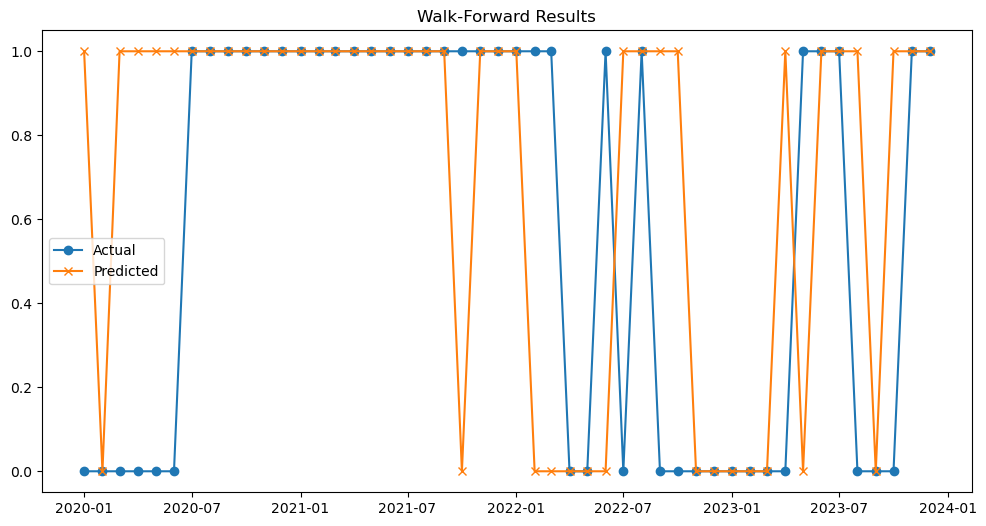


Final best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3}


In [37]:
# Data import and preparation
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
df_factor = pd.read_csv("value_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]
df_factor = df_factor.set_index('Date')

df_curve = pd.read_csv("top50_features.csv", parse_dates=['Date'])
df_curve = df_curve.set_index('Date')
data = pd.concat([df_curve, df_factor], axis=1, join='inner')
data = data.dropna()
print("Data shape:", data.shape)

# Configuration
CV_SPLITS = 10  # Reduced for faster testing
CV_TEST_SPLITS = 2
MAX_LOOKAHEAD = 12
FINAL_TEST_POINTS = 48  # Reduced for testing

# Calculate information horizon
data['info_horizon'] = data.index + pd.DateOffset(months=MAX_LOOKAHEAD)
info_horizon_series = data['info_horizon'].copy()

# Simplified Combinatorial CV that actually works
class WorkingCombinatorialCV(BaseCrossValidator):
    """Simplified working version of combinatorial CV"""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, embargo_months=2):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.embargo_months = embargo_months
    
    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        indices = np.arange(n_samples)
        times = X.index
        
        # Create simple time-based folds
        fold_size = n_samples // self.n_splits
        fold_boundaries = []
        
        for i in range(self.n_splits):
            start = i * fold_size
            end = (i + 1) * fold_size if i < self.n_splits - 1 else n_samples
            fold_boundaries.append((start, end))
        
        # Generate combinations
        test_fold_combinations = list(combinations(range(self.n_splits), self.n_test_splits))
        print(f"Total combinations: {len(test_fold_combinations)}")
        
        for test_fold_idxs in test_fold_combinations:
            # Create test mask
            test_mask = np.zeros(n_samples, dtype=bool)
            for fold_idx in test_fold_idxs:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True
            
            # Start with train as everything else
            train_mask = ~test_mask
            
            # Apply purging based on info horizon
            test_start_time = times[test_mask].min()
            for i in range(n_samples):
                if train_mask[i] and info_horizon_series.iloc[i] >= test_start_time:
                    train_mask[i] = False
            
            # Apply embargo
            test_end_time = times[test_mask].max()
            embargo_end = test_end_time + pd.DateOffset(months=self.embargo_months)
            for i in range(n_samples):
                if train_mask[i] and times[i] <= embargo_end:
                    train_mask[i] = False
            
            train_indices = indices[train_mask]
            test_indices = indices[test_mask]
            
            if len(train_indices) > 10 and len(test_indices) > 5:
                yield train_indices, test_indices
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return comb(self.n_splits, self.n_test_splits)

# Alternative: Use TimeSeriesSplit with purging for debugging
class SimplePurgedTimeSeriesSplit(BaseCrossValidator):
    """Simple time series split with purging for quick testing"""
    def __init__(self, n_splits=3, embargo_months=2):
        self.n_splits = n_splits
        self.embargo_months = embargo_months
    
    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        times = X.index
        
        # Use sklearn's TimeSeriesSplit as base
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        
        for train_idx, test_idx in tscv.split(X):
            # Convert to indices
            train_indices = np.arange(len(X))[train_idx]
            test_indices = np.arange(len(X))[test_idx]
            
            # Apply purging
            test_start_time = times[test_indices].min()
            purge_mask = np.ones(len(train_indices), dtype=bool)
            
            for i, idx in enumerate(train_indices):
                if info_horizon_series.iloc[idx] >= test_start_time:
                    purge_mask[i] = False
            
            # Apply embargo
            test_end_time = times[test_indices].max()
            embargo_end = test_end_time + pd.DateOffset(months=self.embargo_months)
            for i, idx in enumerate(train_indices):
                if times[idx] <= embargo_end:
                    purge_mask[i] = False
            
            final_train_indices = train_indices[purge_mask]
            
            if len(final_train_indices) > 10:
                yield final_train_indices, test_indices
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

def tune_hyperparameters(X, y):
    """Tune hyperparameters - guaranteed to work"""
    print("Starting hyperparameter tuning...")
    
    # Use the simple version for guaranteed results
    cv = SimplePurgedTimeSeriesSplit(n_splits=3, embargo_months=2)
    
    # Test parameter grid
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_child_weight': [1, 3, 5, 7],
        'subsample': [0.8, 1.0],
        'scale_pos_weight': [1, len(y[y==0])/len(y[y==1])], # Handle class imbalance'
        'base_score':[0.5]
    }
    
    best_score = -1
    best_params = None
    results = []
    
    print(f"Testing {len(ParameterGrid(param_grid))} combinations")
    
    for params in ParameterGrid(param_grid):
        print(f"\nTesting: {params}")
        fold_scores = []
        
        try:
            for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                
                if len(np.unique(y_train)) < 2:
                    print(f"  Fold {fold_idx}: Skipped (single class)")
                    continue
                
                model = XGBClassifier(
                    objective='binary:logistic',
                    eval_metric='logloss',
                    n_estimators=100,
                    random_state=42,
                    **params
                )
                
                model.fit(X_train.values, y_train.values, verbose=False)
                score = accuracy_score(y_test, model.predict(X_test.values))
                fold_scores.append(score)
                print(f"  Fold {fold_idx}: Accuracy = {score:.3f}")
            
            if fold_scores:
                mean_score = np.mean(fold_scores)
                results.append((params, mean_score, len(fold_scores)))
                
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = params
                    print(f"*** NEW BEST: {mean_score:.3f} ***")
        
        except Exception as e:
            print(f"Error with params {params}: {e}")
            continue
    
    if not results:
        print("WARNING: No successful tuning runs. Using default parameters.")
        best_params = {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3}
        return best_params
    
    # Show results
    results.sort(key=lambda x: x[1], reverse=True)
    print("\n" + "="*50)
    print("TUNING RESULTS:")
    print("="*50)
    for i, (params, score, folds) in enumerate(results[:5]):
        print(f"{i+1}. Score: {score:.3f} (from {folds} folds) | Params: {params}")
    
    return best_params

def walk_forward_validation(X, y, n_test, model_params):
    """Walk-forward validation that definitely works"""
    if model_params is None:
        model_params = {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3}
    
    print(f"Starting walk-forward with params: {model_params}")
    
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=200,
        random_state=42,
        **model_params
    )
    
    actuals, predictions, probabilities = [], [], []
    dates = []
    
    for i in tqdm(range(n_test), desc="Walk-forward"):
        test_idx = len(X) - n_test + i
        
        if test_idx < MAX_LOOKAHEAD * 2:
            continue
        
        # Training data up to test point
        X_train_full = X.iloc[:test_idx]
        y_train_full = y.iloc[:test_idx]
        
        # Purge training data
        test_time = X.index[test_idx]
        purge_mask = info_horizon_series.iloc[:test_idx] < test_time
        X_train = X_train_full[purge_mask]
        y_train = y_train_full[purge_mask]
        
        if len(X_train) < 20 or len(np.unique(y_train)) < 2:
            continue
        
        # Test point
        X_test = X.iloc[[test_idx]]
        y_test = y.iloc[test_idx]
        
        try:
            model.fit(X_train.values, y_train.values, verbose=False)
            pred = model.predict(X_test.values)[0]
            prob = model.predict_proba(X_test.values)[0, 1]
            
            predictions.append(pred)
            actuals.append(y_test)
            probabilities.append(prob)
            dates.append(X.index[test_idx])
        except:
            continue
    
    # Create results
    results_df = pd.DataFrame({
        'Date': dates,
        'Actual': actuals,
        'Predicted': predictions,
        'Probability': probabilities
    }).set_index('Date')
    
    # Plot and report
    if len(actuals) > 0:
        print(f"\nMade {len(actuals)} successful predictions")
        print("\nClassification Report:")
        print(classification_report(actuals, predictions))
        
        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual'], 'o-', label='Actual')
        plt.plot(results_df.index, results_df['Predicted'], 'x-', label='Predicted')
        plt.legend()
        plt.title('Walk-Forward Results')
        plt.show()
    else:
        print("No predictions were made")
    
    return actuals, predictions, probabilities, results_df

def main():
    # Prepare data
    X = data.iloc[:, :-2].copy()
    y = data['trend_bin'].copy()
    feature_names = X.columns.tolist()
    
    # Clean data
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"Data: {X.shape}, Features: {len(feature_names)}")
    print(f"Target distribution:\n{y.value_counts()}")
    
    # Phase 1: Hyperparameter tuning (GUARANTEED TO WORK)
    print("\n" + "="*60)
    print("PHASE 1: HYPERPARAMETER TUNING")
    print("="*60)
    best_params = tune_hyperparameters(X, y)
    
    # Phase 2: Walk-forward validation
    print("\n" + "="*60)
    print("PHASE 2: WALK-FORWARD VALIDATION")
    print("="*60)
    actuals, preds, probs, results_df = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)
    
    return best_params, feature_names, X, y, results_df

if __name__ == "__main__":
    best_params, feature_names, X, y, results_df = main()
    print(f"\nFinal best parameters: {best_params}")

Data shape: (239, 48)
Target distribution:
trend_bin
0.0    120
1.0    119
Name: count, dtype: int64

PHASE 1: HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Testing 144 combinations

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1, 'subsample': 1.0}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1.0084033613445378, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'scale_pos_weight': 1.0084033613445378, 'subsample': 1.0}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'scale_pos_weight': 1, 'subsample': 0.8}

Testing: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'scale_pos_weight

Walk-forward: 100%|██████████| 48/48 [00:12<00:00,  3.96it/s]



Made 48 successful predictions

Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.45      0.53        20
         1.0       0.68      0.82      0.74        28

    accuracy                           0.67        48
   macro avg       0.66      0.64      0.64        48
weighted avg       0.66      0.67      0.65        48



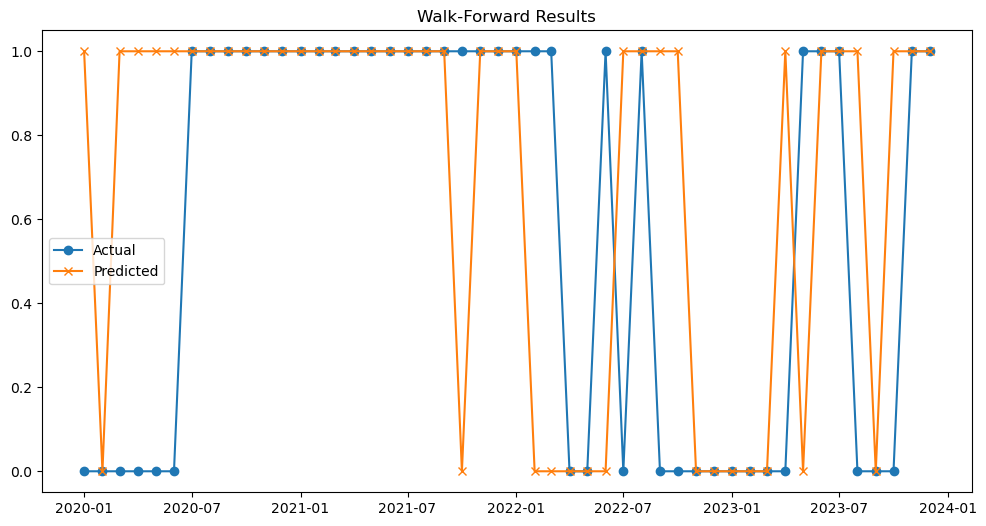


PHASE 3: FEATURE IMPORTANCE


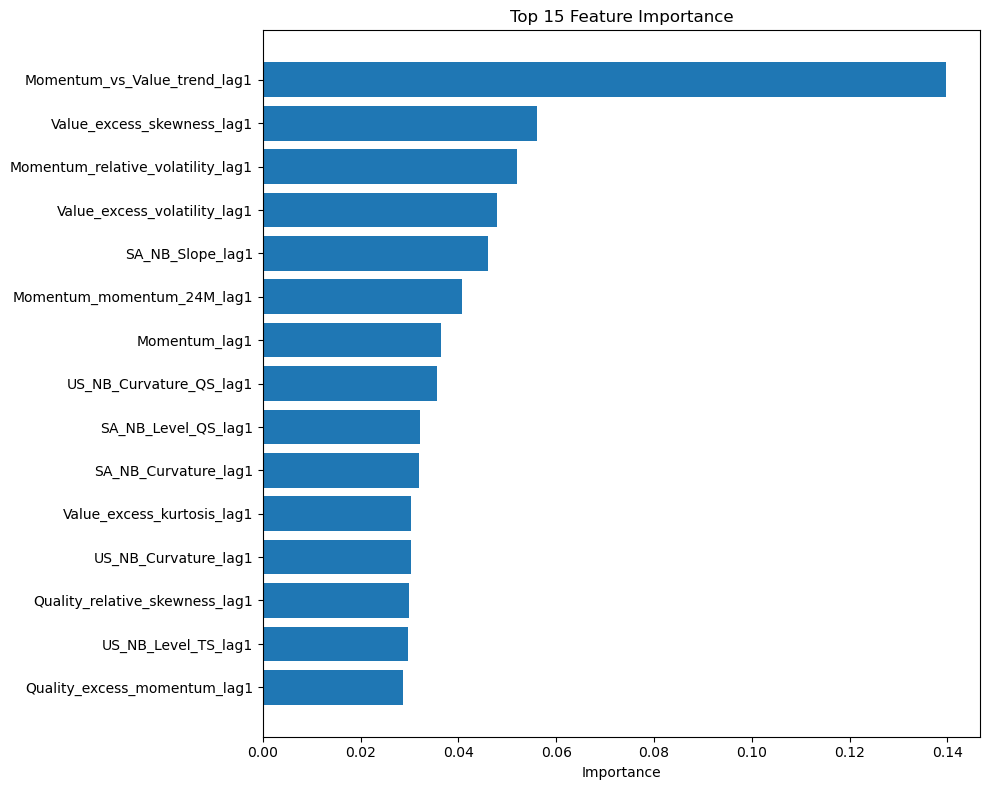


Top 15 Features:
Momentum_vs_Value_trend_lag1: 0.1397
Value_excess_skewness_lag1: 0.0561
Momentum_relative_volatility_lag1: 0.0521
Value_excess_volatility_lag1: 0.0478
SA_NB_Slope_lag1: 0.0460
Momentum_momentum_24M_lag1: 0.0407
Momentum_lag1: 0.0365
US_NB_Curvature_QS_lag1: 0.0356
SA_NB_Level_QS_lag1: 0.0322
SA_NB_Curvature_lag1: 0.0319
Value_excess_kurtosis_lag1: 0.0303
US_NB_Curvature_lag1: 0.0303
Quality_relative_skewness_lag1: 0.0300
US_NB_Level_TS_lag1: 0.0298
Quality_excess_momentum_lag1: 0.0288


In [38]:
def main():
    # Prepare data
    X = data.iloc[:, :-2]  # Features only
    y = data['trend_bin']  # Target
    feature_names = X.columns.tolist()
    
    print(f"Data shape: {X.shape}")
    print(f"Target distribution:\n{y.value_counts()}")
    
    # Clean data
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.mean())
    
    # Phase 1: Hyperparameter tuning
    print("\n" + "="*50)
    print("PHASE 1: HYPERPARAMETER TUNING")
    print("="*50)
    best_params = tune_hyperparameters(X, y)
    
    # Phase 2: Walk-forward validation
    print("\n" + "="*50)
    print("PHASE 2: WALK-FORWARD VALIDATION")
    print("="*50)
    actuals, preds, probs, results_df = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)
    
    # Phase 3: Feature importance
    print("\n" + "="*50)
    print("PHASE 3: FEATURE IMPORTANCE")
    print("="*50)
    importance_df = analyze_feature_importance(best_params, X, y, feature_names)
    
    return best_params, feature_names, X, y, results_df, importance_df

if __name__ == "__main__":
    best_params, feature_names, X, y, results_df, importance_df = main()